Global Climate Trends Analysis

## 1. Temperature Analysis

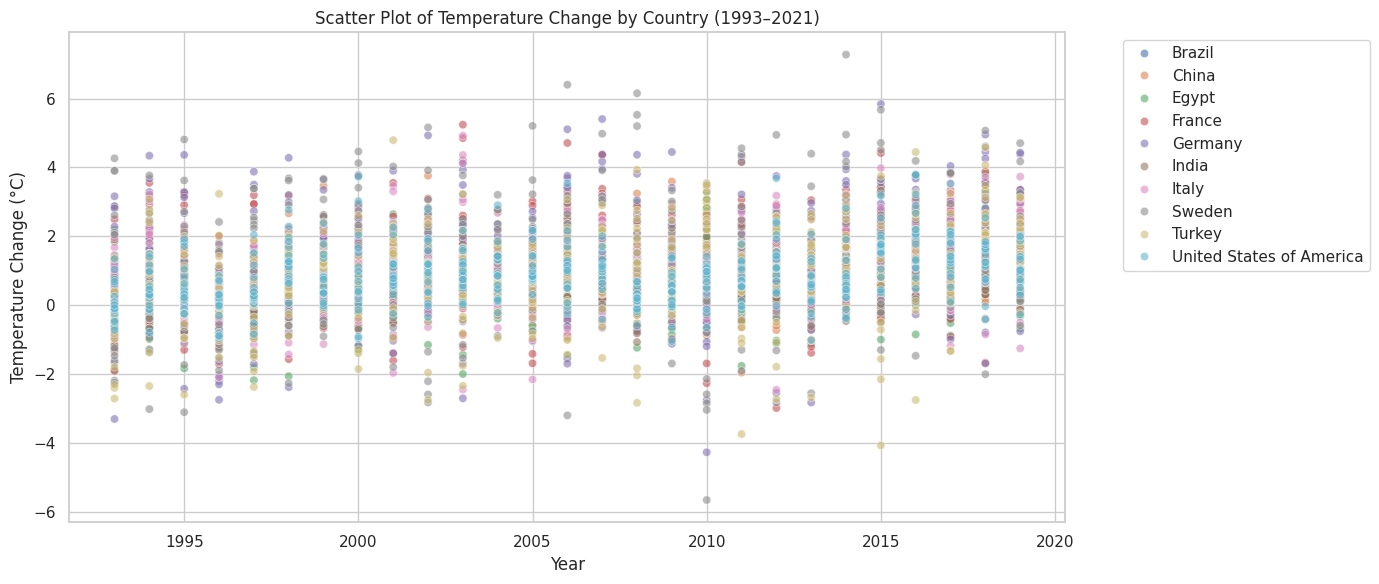

<ipython-input-6-f27a22df5ba9>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_temp.values, y=avg_temp.index, palette="coolwarm")


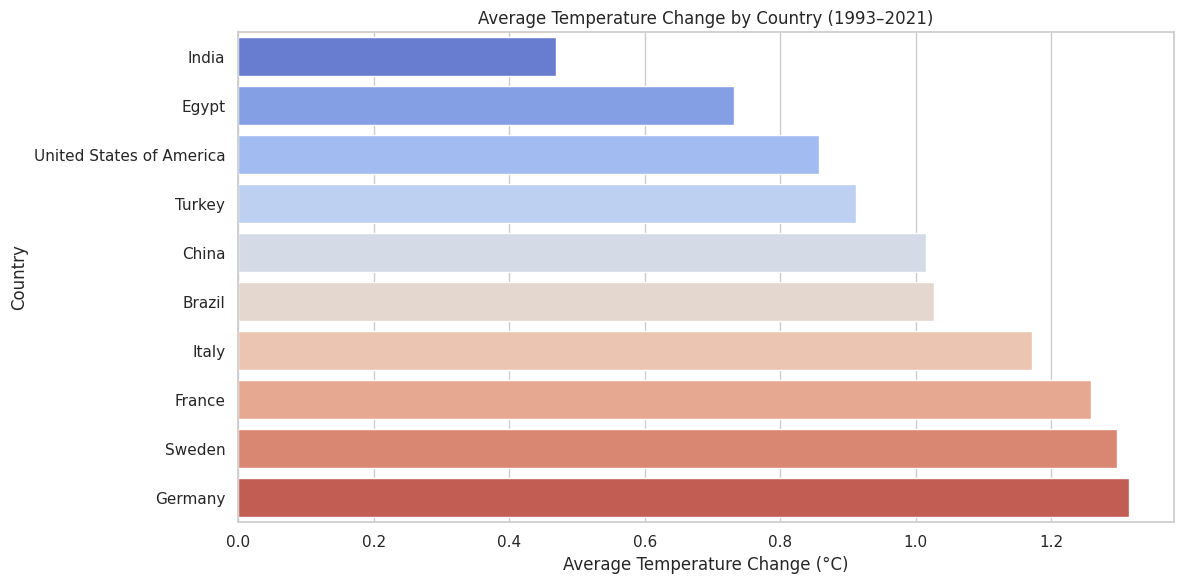

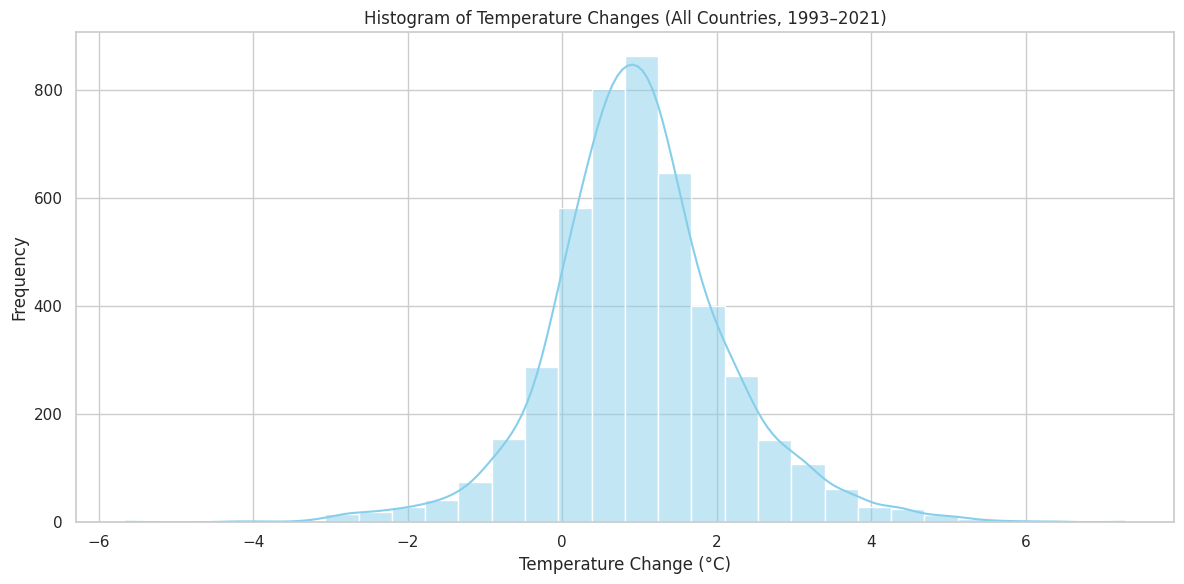

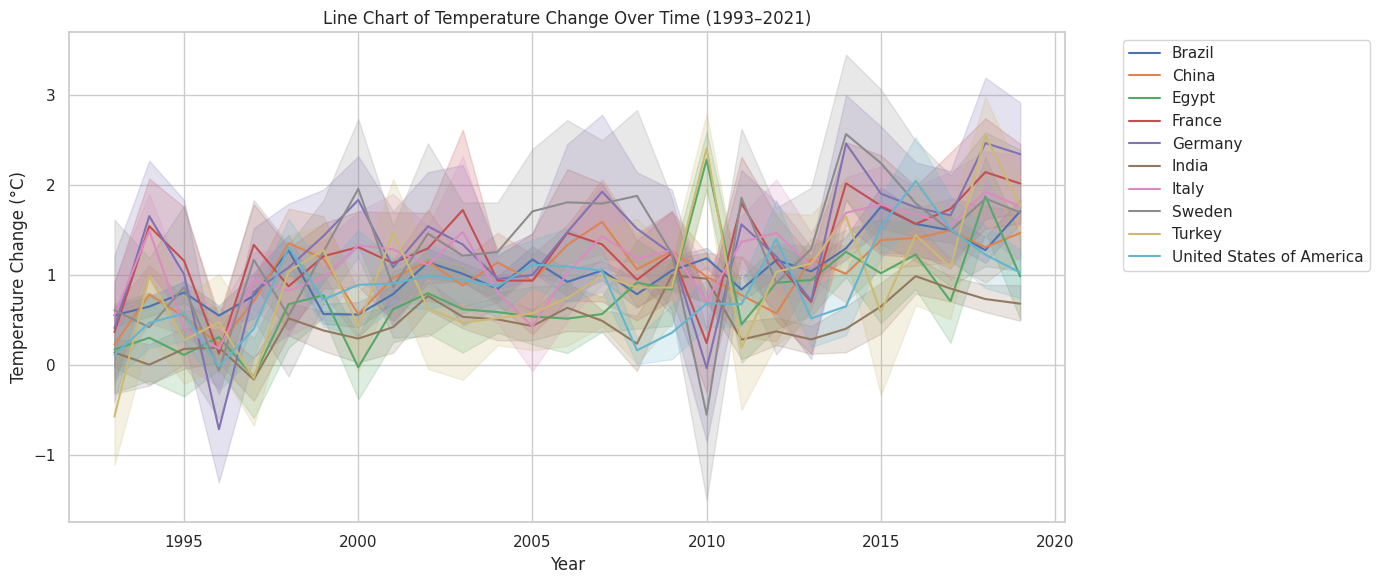

<ipython-input-6-f27a22df5ba9>:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Country", y="Temp_Change_C", palette="Set2")


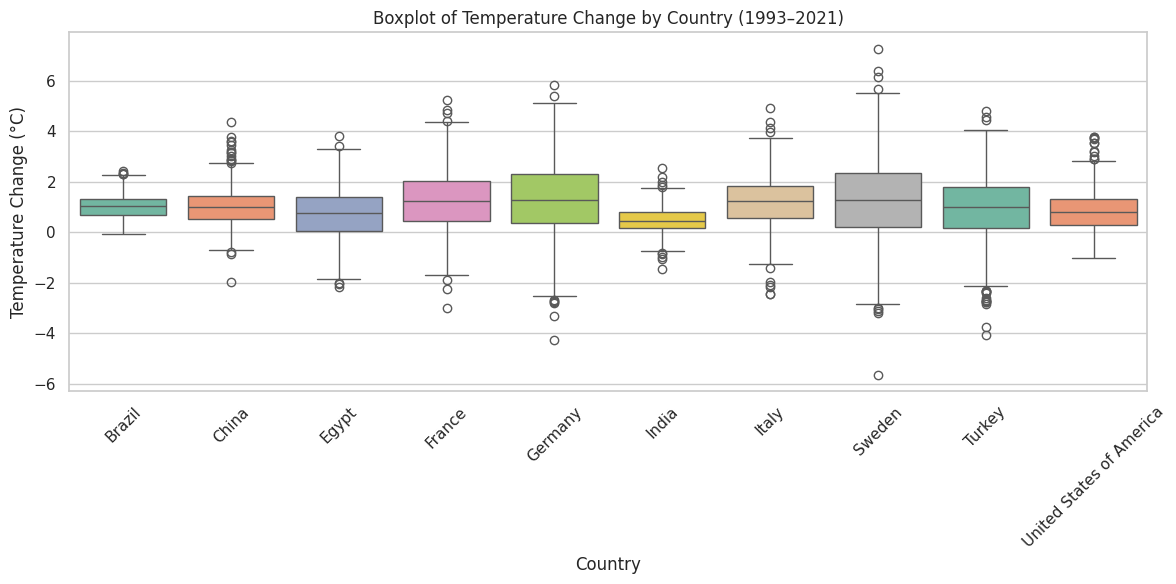


🔍 KEY INSIGHTS (1993–2021):

🌡️ Highest average temperature change: Germany (1.32°C)
❄️ Lowest average temperature change: India (0.47°C)
📈 Most variable temperature change: Sweden (Std Dev: 1.74)
📊 Overall trend: From 0.25°C in 1993 to 1.54°C in 2019


In [ ]:
## 1. Temperature Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'temp.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

target_countries = ["United States of America", "China", "France", "Italy", "Germany","Turkey", "India", "Brazil", "Sweden", "Egypt"]

# Filter and reshape
df_filtered = df[(df["Element"] == "Temperature change") & (df["Area"].isin(target_countries))]
df_long = df_filtered.melt(id_vars=["Area"],value_vars=[col for col in df.columns if col.startswith("Y")],var_name="Year",value_name="Temp_Change_C")
df_long["Year"] = df_long["Year"].str.extract(r'(\d+)', expand=False).astype(int)
df_long.rename(columns={"Area": "Country"}, inplace=True)
df_cleaned = df_long.dropna()
df_cleaned = df_cleaned[(df_cleaned["Year"] >= 1993) & (df_cleaned["Year"] <= 2021)]
df_cleaned = df_cleaned.sort_values(by=["Country", "Year"]).reset_index(drop=True)

sns.set(style="whitegrid")

# Scatter Plot
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_cleaned, x="Year", y="Temp_Change_C", hue="Country", alpha=0.6)
plt.title("Scatter Plot of Temperature Change by Country (1993–2021)")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Bar Chart
plt.figure(figsize=(12, 6))
avg_temp = df_cleaned.groupby("Country")["Temp_Change_C"].mean().sort_values()
sns.barplot(x=avg_temp.values, y=avg_temp.index, palette="coolwarm")
plt.title("Average Temperature Change by Country (1993–2021)")
plt.xlabel("Average Temperature Change (°C)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned["Temp_Change_C"], bins=30, kde=True, color="skyblue")
plt.title("Histogram of Temperature Changes (All Countries, 1993–2021)")
plt.xlabel("Temperature Change (°C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_cleaned, x="Year", y="Temp_Change_C", hue="Country")
plt.title("Line Chart of Temperature Change Over Time (1993–2021)")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned, x="Country", y="Temp_Change_C", palette="Set2")
plt.title("Boxplot of Temperature Change by Country (1993–2021)")
plt.xlabel("Country")
plt.ylabel("Temperature Change (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary
print("Temperature (1993–2021):\n")

highest_avg = avg_temp.idxmax()
lowest_avg = avg_temp.idxmin()

spread = df_cleaned.groupby("Country")["Temp_Change_C"].std().sort_values(ascending=False)
most_variable = spread.idxmax()

overall_trend = df_cleaned.groupby("Year")["Temp_Change_C"].mean()



#2 CO₂ Emissions Analysis

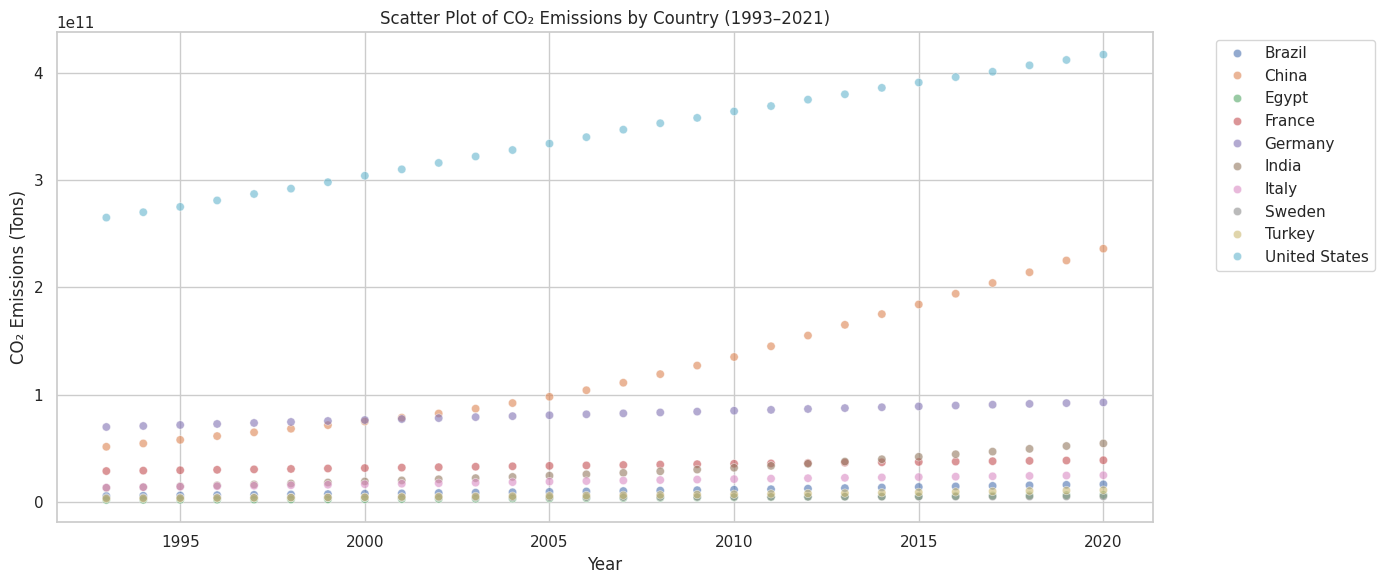

<ipython-input-10-a2485777c95f>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_co2.values, y=avg_co2.index, palette="crest")


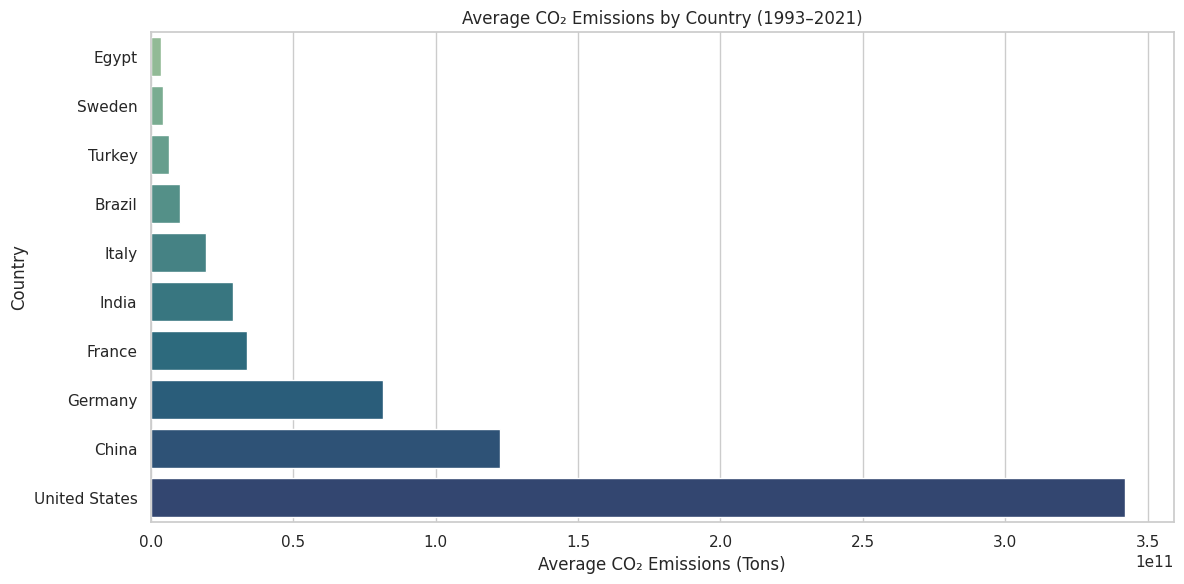

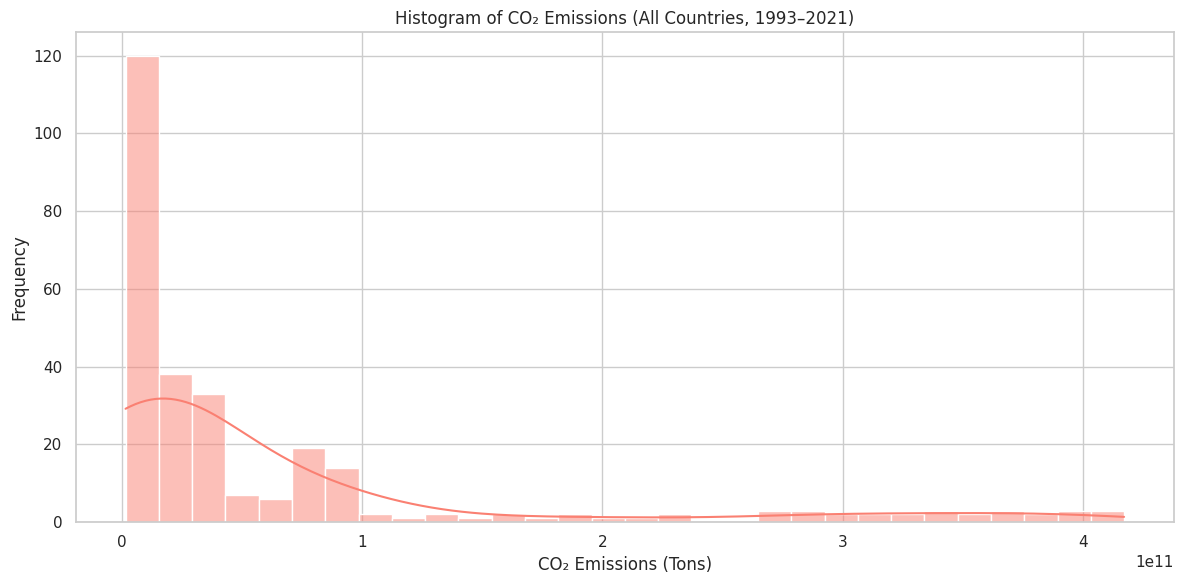

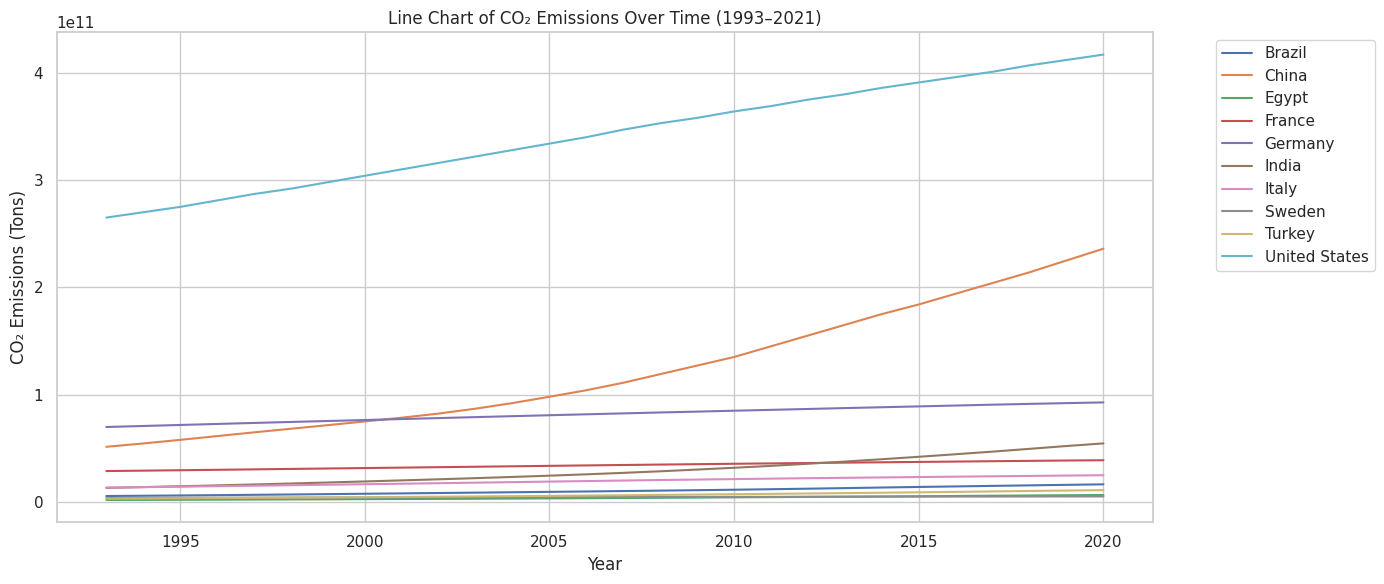

<ipython-input-10-a2485777c95f>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Country", y="CO2_Tons", palette="Set3")


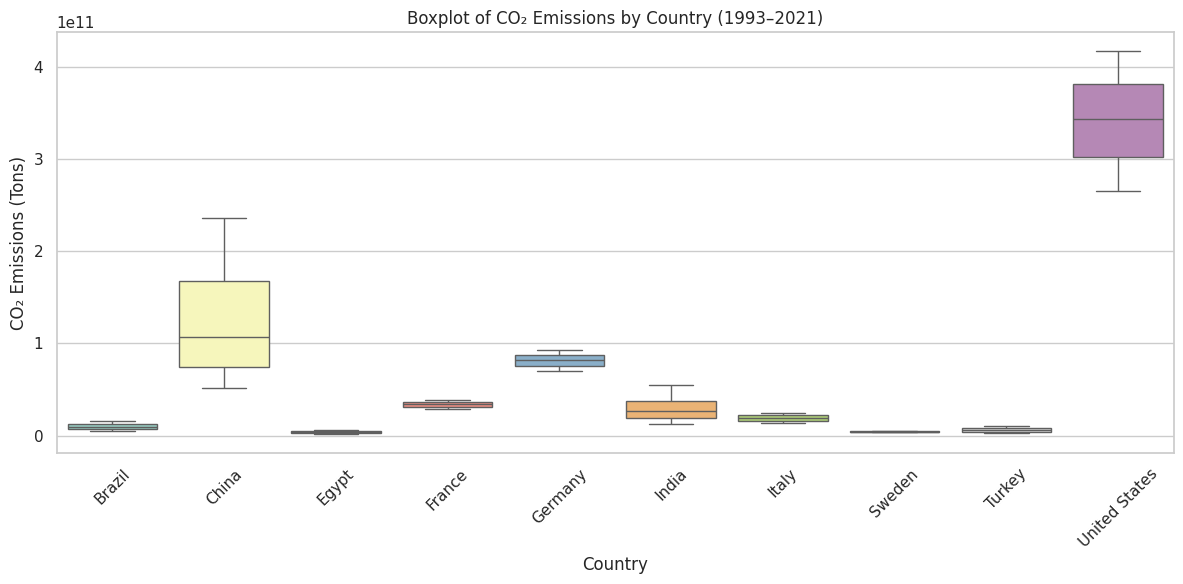

CO2 Summary:



In [ ]:
# 2 CO2 Dataset


file_path = 'CO2.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

target_countries = ["United States", "China", "France", "Italy", "Germany","Turkey", "India", "Brazil", "Sweden", "Egypt"]

# Filter
df_filtered = df[df["Country"].isin(target_countries)]
df_filtered = df_filtered[(df_filtered["Year"] >= 1993) & (df_filtered["Year"] <= 2021)]

df_cleaned = df_filtered[["Country", "Year", "CO2 emission (Tons)"]].dropna()
df_cleaned.rename(columns={"CO2 emission (Tons)": "CO2_Tons"}, inplace=True)
df_cleaned = df_cleaned.sort_values(by=["Country", "Year"]).reset_index(drop=True)

sns.set(style="whitegrid")

# Scatter Plot
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_cleaned, x="Year", y="CO2_Tons", hue="Country", alpha=0.6)
plt.title("Scatter Plot of CO₂ Emissions by Country (1993–2021)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Tons)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Bar Chart
plt.figure(figsize=(12, 6))
avg_co2 = df_cleaned.groupby("Country")["CO2_Tons"].mean().sort_values()
sns.barplot(x=avg_co2.values, y=avg_co2.index, palette="crest")
plt.title("Average CO₂ Emissions by Country (1993–2021)")
plt.xlabel("Average CO₂ Emissions (Tons)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned["CO2_Tons"], bins=30, kde=True, color="salmon")
plt.title("Histogram of CO₂ Emissions (All Countries, 1993–2021)")
plt.xlabel("CO₂ Emissions (Tons)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_cleaned, x="Year", y="CO2_Tons", hue="Country")
plt.title("Line Chart of CO₂ Emissions Over Time (1993–2021)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Tons)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned, x="Country", y="CO2_Tons", palette="Set3")
plt.title("Boxplot of CO₂ Emissions by Country (1993–2021)")
plt.xlabel("Country")
plt.ylabel("CO₂ Emissions (Tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary
print("CO2 Summary:\n")

# Max min avg co2 emmission
highest_avg = avg_co2.idxmax()
lowest_avg = avg_co2.idxmin()

spread = df_cleaned.groupby("Country")["CO2_Tons"].std().sort_values(ascending=False)
most_variable = spread.idxmax()

overall_trend = df_cleaned.groupby("Year")["CO2_Tons"].mean()



 #3 Global Sea Level Analysis

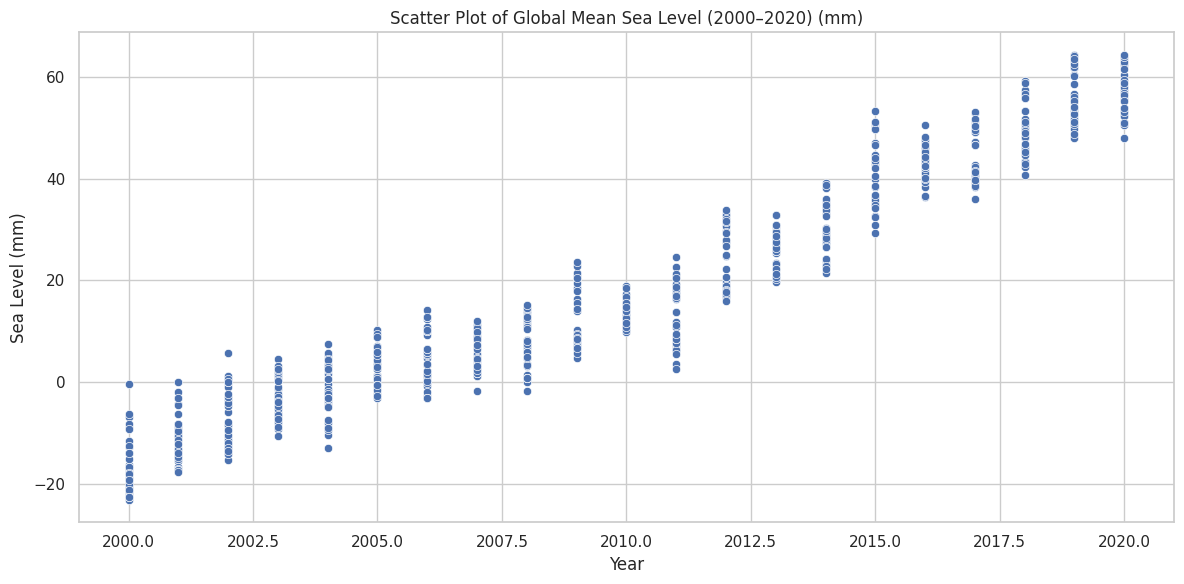

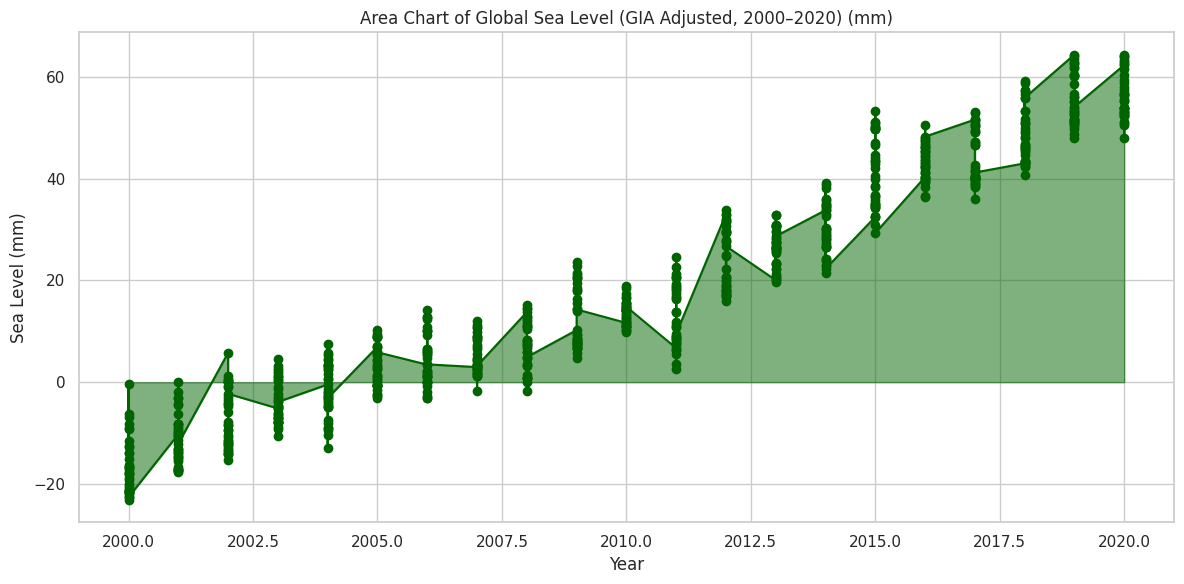

Global Sea Level (2000–2020) (mm)

-17.98
50.91
Year            2019.00
Sea_Level_mm      64.39
Name: 699, dtype: float64
Year            2000.00
Sea_Level_mm     -23.15
Name: 32, dtype: float64
22.634750737841767


In [ ]:
# 3 Sea Level dataset

sealevel_df = pd.read_csv('sealevel.csv')

# Step 1: Filter, drop missing, sort, and rename in one clean step
df = (sealevel_df[["Year", "GMSL_GIA"]].dropna().rename(columns={"GMSL_GIA": "Sea_Level_mm"}).query("2000 <= Year <= 2020").sort_values(by="Year").reset_index(drop=True))

# Visualization setup
sns.set(style="whitegrid")

# Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="Year", y="Sea_Level_mm")
plt.title("Scatter Plot of Global Mean Sea Level (2000–2020) (mm)")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.tight_layout()
plt.show()

# Area Plot
plt.figure(figsize=(12, 6))
plt.fill_between(df["Year"], df["Sea_Level_mm"], color="darkgreen", alpha=0.5)
plt.plot(df["Year"], df["Sea_Level_mm"], marker="o", color="darkgreen")
plt.title("Area Chart of Global Sea Level (GIA Adjusted, 2000–2020) (mm)")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.tight_layout()
plt.show()

# Summary
print("Global Sea Level (2000–2020) (mm)\n")

# Sea levels range
start_level = df.iloc[0]["Sea_Level_mm"]
end_level = df.iloc[-1]["Sea_Level_mm"]

# Sea levels years
max_sl = df.loc[df["Sea_Level_mm"].idxmax()]
print(max_sl)
min_sl = df.loc[df["Sea_Level_mm"].idxmin()]
print(min_sl)

# Standart deviation
std_dev = df["Sea_Level_mm"].std()
print(std_dev)

